In [4]:
import functools
import importlib
import os
import sys
from typing import Callable, Dict

sys.path.append('../../py')

import click
import common.fid_utils as fid_utils
import common.flow_map as flow_map
import common.state_utils as state_utils
import common.velocity as velocity
import flax
import jax
import jax.numpy as jnp
import numpy as np
from tqdm.auto import tqdm

2025-09-30 15:35:35.698625: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-30 15:35:35.753365: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759260935.769122 2586855 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759260935.773875 2586855 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759260935.786670 2586855 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# Image Generation

In [8]:
def define_sampler(cfg: Dict) -> Callable:
    return (
        velocity.batch_sample if cfg.training.train_velocity else flow_map.batch_sample
    )

In [13]:
model_folder = "/n/netscratch/albergo_lab/Everyone/nmboffi/celeba"

#  (checkpoint_path, ema, slurm_id, cfg_module, pretty_label)
DATA = [
    (f"{model_folder}/celeba_lsd_stopgrad_convex_diag75_bs256_9_8_resumed_120.pkl", 0.9999, 0, "configs.9_8_25_celeba_loss_method_resume", "LSD"),
    (f"{model_folder}/celeba_pfmm_shortcut_stopgrad_convex_diag75_bs256_9_8_resumed_120.pkl", 0.9999, 2, "configs.9_8_25_celeba_loss_method_resume", "PSD-M"),
    (f"{model_folder}/celeba_pfmm_uniform_stopgrad_convex_diag75_bs256_9_8_resumed_85.pkl", 0.9999, 1, "configs.9_8_25_celeba_loss_method_resume", "PSD-U"),
]


N_STEPS = [1, 2, 4, 8, 16]
N_SHOW  = 8
SEED    = 32


# ----------------------------------------------------------------
import os, functools, importlib, jax, jax.numpy as jnp, numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import flax
plt.rcParams['text.usetex'] = False


def make_grid(imgs, n_cols=N_SHOW):
    B, H, W, C = imgs.shape
    n_rows = (B + n_cols - 1) // n_cols
    canvas = np.ones((n_rows*H, n_cols*W, C), dtype=imgs.dtype)
    for idx, im in enumerate(imgs):
        r, c = divmod(idx, n_cols)
        canvas[r*H:(r+1)*H, c*W:(c+1)*W] = im
    return canvas

Number of parameters: 124264485
saved → celeba64_LSD.png


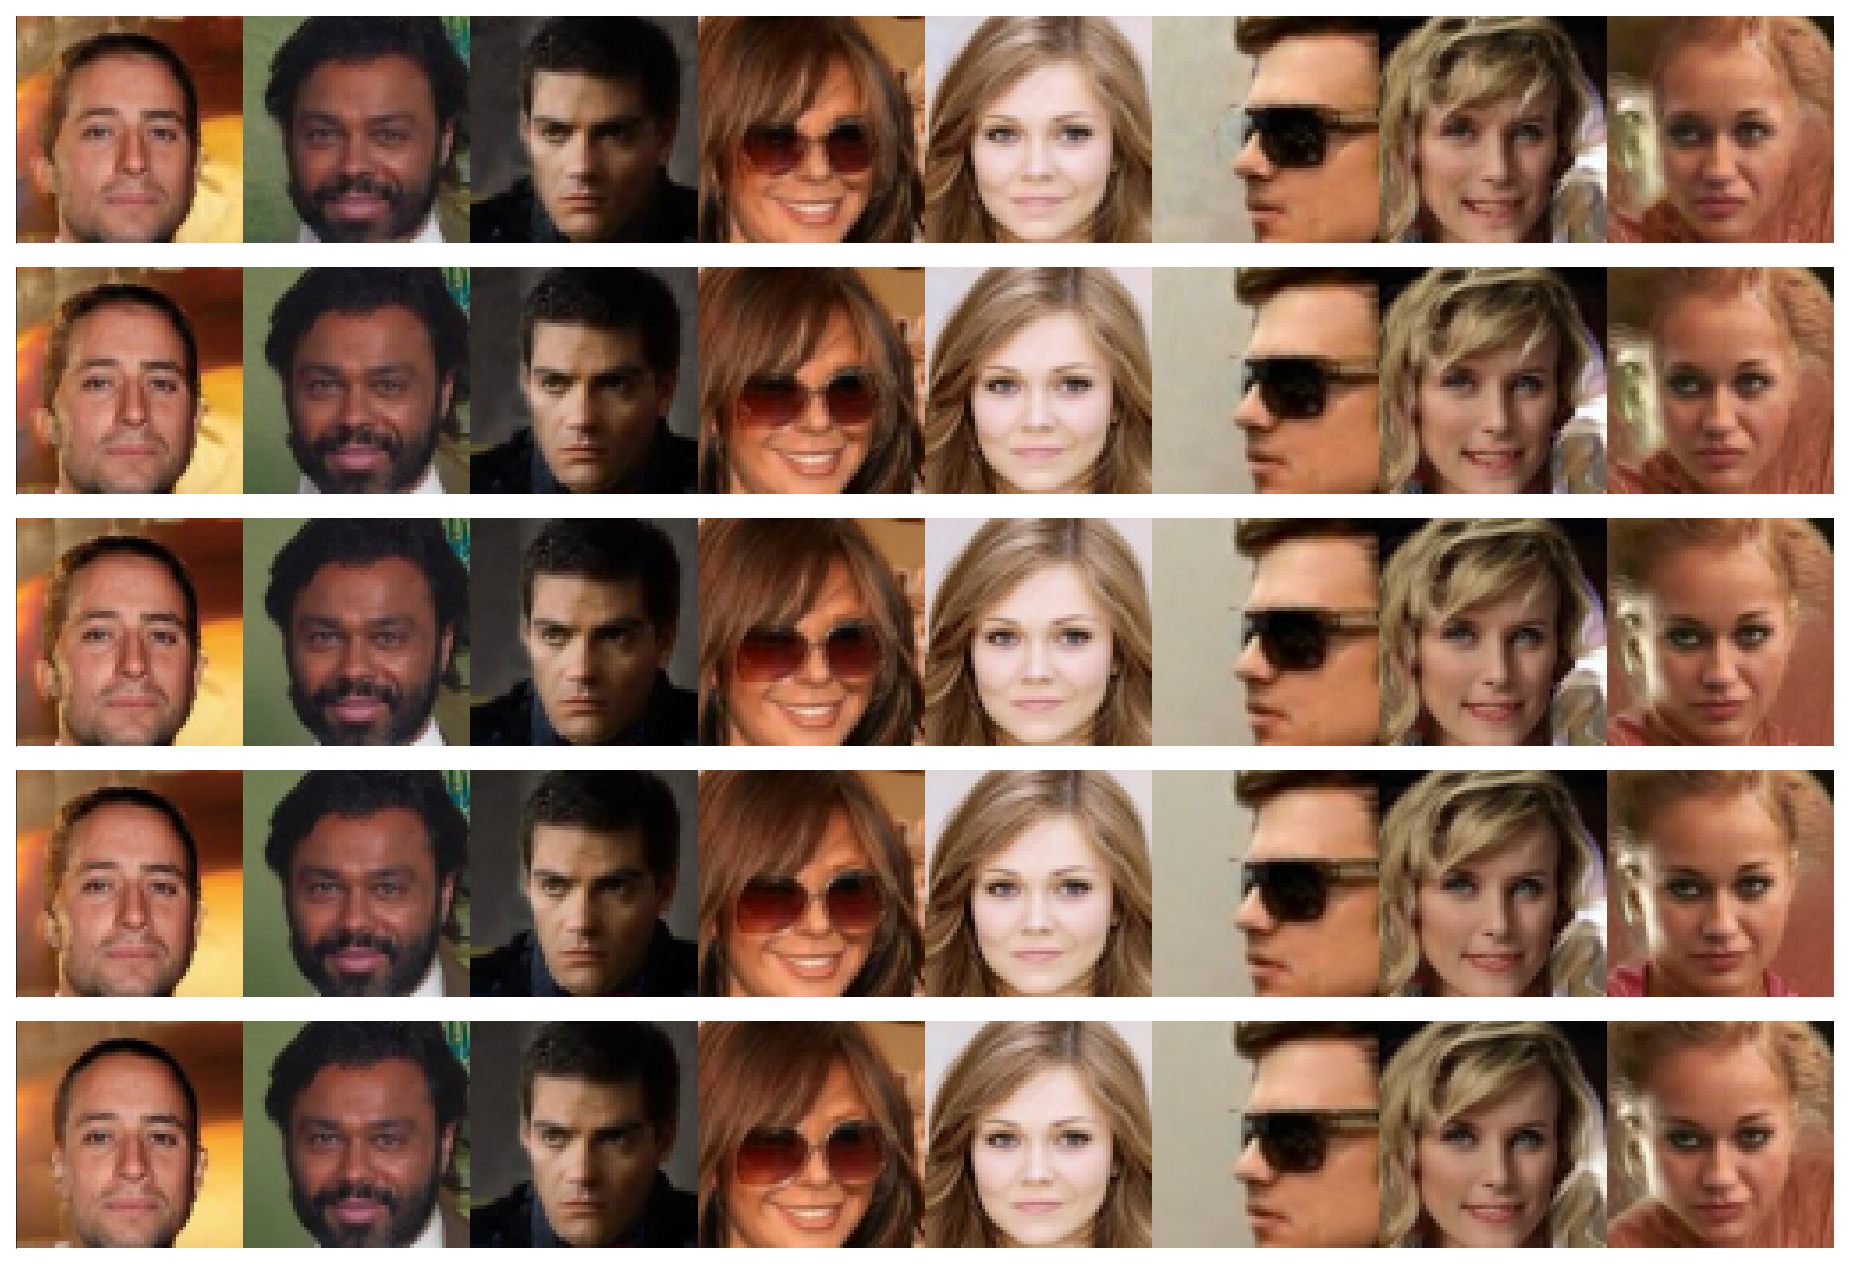

Number of parameters: 124264485
saved → celeba64_PSD-M.png


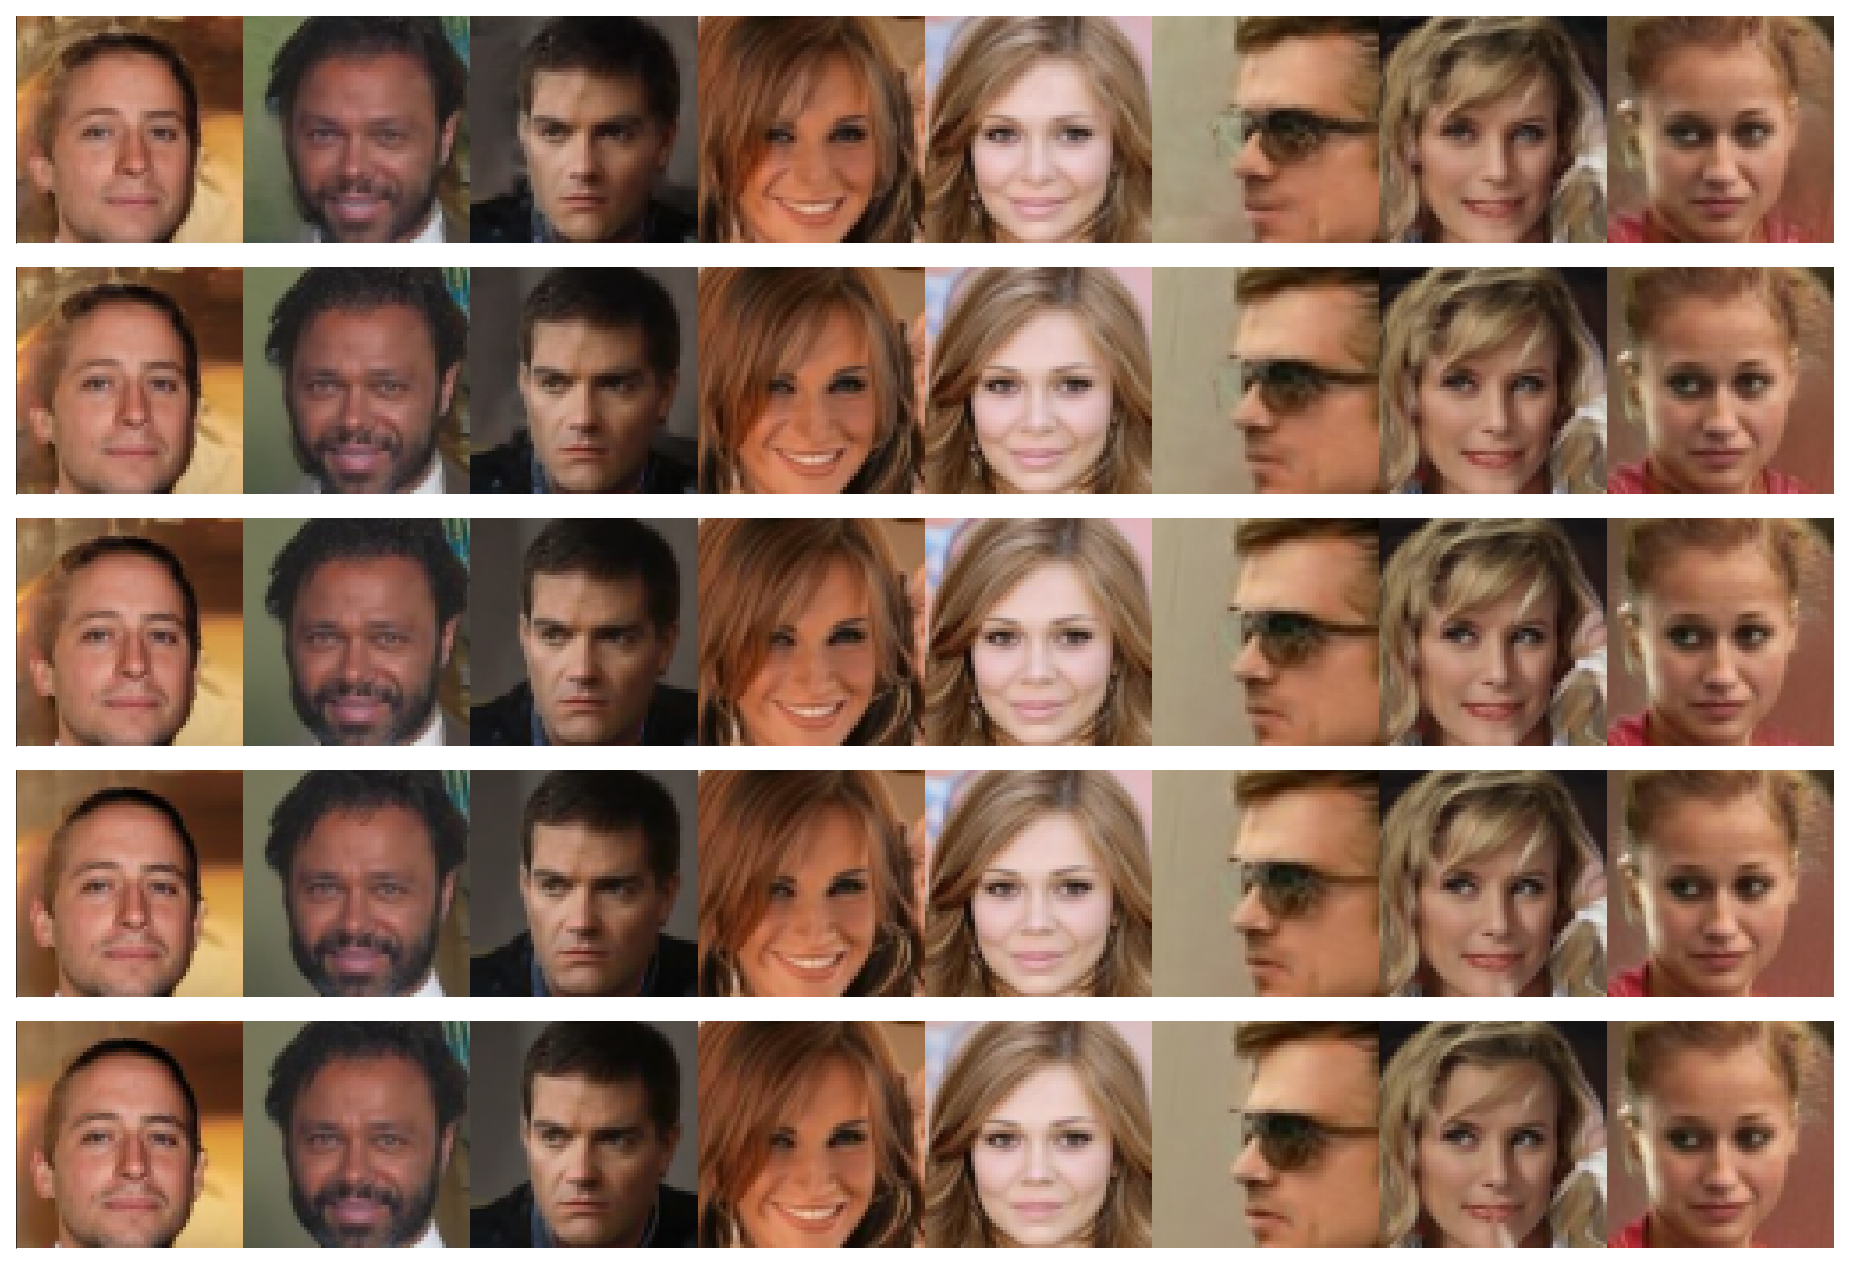

Number of parameters: 124264485
saved → celeba64_PSD-U.png


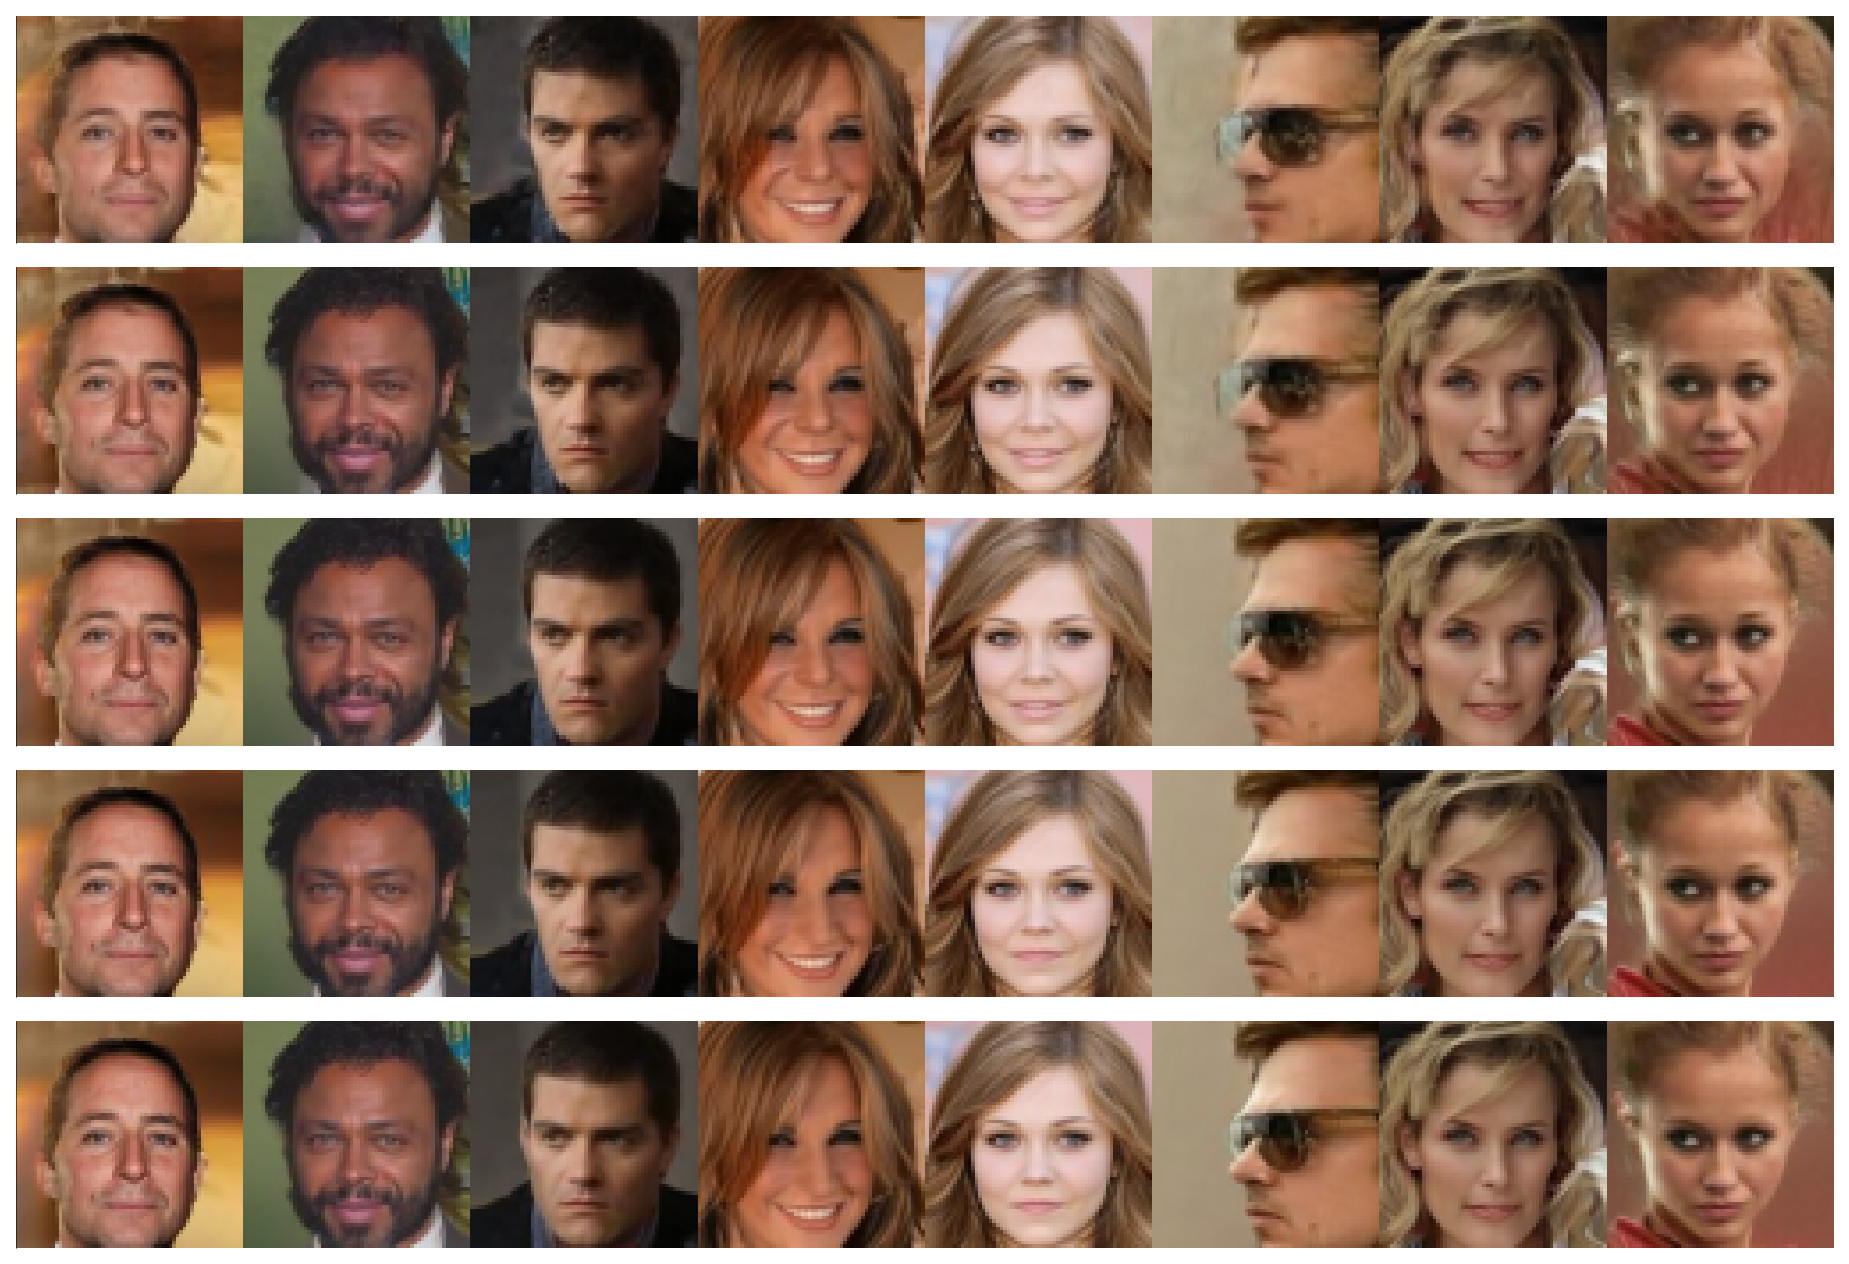

In [14]:
def sample_grid(ckpt_path, ema, slurm_id, cfg_module, x0s):
    cfg = importlib.import_module(cfg_module).get_config(slurm_id, "", "")
    if cfg.problem.gaussian_scale == "adaptive":
        cfg.network.rescale = 0.5 if cfg.problem.target in {"mnist", "cifar10", "celeb_a"} else 1.0
    sampler_fn = define_sampler(cfg)

    # net skeleton
    net, params, _ = (
        velocity.initialize_velocity
        if cfg.training.train_velocity else flow_map.initialize_flow_map
    )(cfg.network, jnp.zeros(cfg.problem.image_dims), jax.random.PRNGKey(SEED))

    # load checkpoint
    with open(ckpt_path, "rb") as f:
        dummy_tx, _ = state_utils.setup_optimizer(cfg)
        ts = state_utils.EMATrainState.create(apply_fn=net.apply, params=params, ema_params={ema: params}, tx=dummy_tx)
        ts = flax.serialization.from_bytes(ts, f.read())
    params = ts.ema_params[ema] if ema else ts.params

    # sample per N
    grids = []
        
    for n in N_STEPS:
        imgs = sampler_fn(net.apply, params, x0s, n, None)
        imgs = ((jnp.clip(imgs, -1, 1).transpose(0, 2, 3, 1) + 1) / 2).astype(np.float32)
        grids.append(make_grid(np.asarray(imgs)))
    return grids


# --------- display for every entry in DATA ----------------------
@functools.partial(jax.jit, static_argnums=(0,))
def sample_rho0(bs, key):
    return 0.5 * jax.random.normal(
        key, (bs, 3, 64, 64)
    )

key = jax.random.PRNGKey(SEED)
x0s = sample_rho0(N_SHOW, key)


# --------- display *and save* for every entry in DATA -------------
for ckpt, ema, sid, cfg_mod, label in DATA:
    grids = sample_grid(ckpt, ema, sid, cfg_mod, x0s)
    n_rows = len(N_STEPS)

    fig, axes = plt.subplots(
        n_rows, 1,
        figsize=(N_SHOW*1.6, n_rows*1.6),
        dpi=160,
        tight_layout=True           # avoids the latex / layout call later
    )
    if n_rows == 1:
        axes = [axes]

    for ax, grid, n in zip(axes, grids, N_STEPS):
        ax.imshow(grid)
        # ax.set_ylabel(rf"$N={n}$", fontsize=18)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel("")   # remove ticks

        # turn off frame except for the y-label side
        for spine in ("top", "right", "bottom"):
            ax.spines[spine].set_visible(False)

    # drop the title entirely
    # fig.suptitle(label, fontsize=10)  ← removed

    # ---------------- save & (optionally) show --------------------
    out_name = f"celeba64_{label.replace(' ', '_')}.png"    # e.g. LSD.png
    fig.savefig(out_name, dpi=160, bbox_inches="tight")
    print("saved →", out_name)
    plt.show()

# Tabular Visualization

In [16]:
import os, glob, re, numpy as np, pandas as pd

def highlight_min_per_title_column(data):
    """Highlight minimum value in each column within each title group"""
    result = pd.DataFrame('', index=data.index, columns=data.columns)
    
    # Get the title level from the index
    titles = data.index.get_level_values('title')
    
    # For each unique title
    for title in titles.unique():
        # Get rows for this title
        title_mask = titles == title
        title_data = data.loc[title_mask]
        
        # For each column (nsteps), find and highlight the minimum
        for col in data.columns:
            if title_data[col].notna().any():
                min_idx = title_data[col].idxmin()
                result.loc[min_idx, col] = 'background-color: lightblue'
    
    return result

DATA_DIR = "/n/netscratch/albergo_lab/Everyone/nmboffi/celeba/fids"
TITLE_FILTER = ['fid_celeba_pfmm_uniform_stopgrad_convex_diag75_bs256_9_8_resumed',
                'fid_celeba_pfmm_shortcut_stopgrad_convex_diag75_bs256_9_8_resumed',
                'fid_celeba_lsd_stopgrad_convex_diag75_bs256_9_8_resumed']

files = glob.glob(os.path.join(DATA_DIR, "*.npz"))

# Updated regex to handle new format: [title]_diag[fac]_no_anneal_[date]_ema=[ema]_N=[nsteps].npz
rx_new = re.compile(
    r"""^
        (?P<title>.+?)                  # title (non-greedy to stop at _diag)
        _diag(?P<diag_fac>\d+)         # diagonal factor
        _no_anneal                      # fixed string
        _(?P<month>\d+)                 # month
        _(?P<day>\d+)                   # day  
        _(?P<checkpoint>\d+)            # checkpoint number
        _ema=(?P<ema>[0-9.]+)          # ema value
        _N=(?P<nsteps>\d+)             # N value
        \.npz$                         # extension
    """,
    re.VERBOSE,
)

# Original regex for backward compatibility
rx_old = re.compile(
    r"""^
        (?P<title>.+)                  # everything before checkpoint
        _(?P<checkpoint>\d+)            # last number before ema
        _ema=(?P<ema>[0-9.]+)          # ema value
        _N=(?P<nsteps>\d+)             # N value
        \.npz$                         # extension
    """,
    re.VERBOSE,
)

records = []
for path in files:
    basename = os.path.basename(path)
    
    # Try new format first
    m = rx_new.match(basename)
    if m:
        with np.load(path) as z:
            fid = float(z["fid"])
        
        rec = m.groupdict()
        # Combine title with diag_fac and date for unique identification
        rec["title"] = f"{rec['title']}_diag{rec['diag_fac']}_no_anneal_{rec['month']}_{rec['day']}"
        rec["checkpoint"] = int(rec["checkpoint"])
        rec["ema"] = float(rec["ema"])
        rec["nsteps"] = int(rec["nsteps"])
        rec["fid"] = fid
        rec["diag_fac"] = int(rec["diag_fac"])  # Keep diag_fac as separate field too
        
        records.append(rec)
        continue
    
    # Try old format
    m = rx_old.match(basename)
    if m:
        with np.load(path) as z:
            fid = float(z["fid"])
        
        rec = m.groupdict()
        rec["checkpoint"] = int(rec["checkpoint"])
        rec["ema"] = float(rec["ema"])
        rec["nsteps"] = int(rec["nsteps"])
        rec["fid"] = fid
        rec["diag_fac"] = None  # No diag_fac in old format
        
        records.append(rec)
        continue
    
    print("⚠️  skipped:", basename)

df = pd.DataFrame(records)
if df.empty:
    raise SystemExit("No files matched!")

# Apply title filter if specified
if TITLE_FILTER is not None:
    if isinstance(TITLE_FILTER, str):
        # Single title
        df = df[df["title"] == TITLE_FILTER]
        print(f"Filtering for title: {TITLE_FILTER}")
    elif isinstance(TITLE_FILTER, list):
        # Multiple titles
        df = df[df["title"].isin(TITLE_FILTER)]
        print(f"Filtering for titles: {TITLE_FILTER}")
    
    if df.empty:
        print("\n⚠️  No files matched the title filter!")
        print(f"Available titles: {sorted(pd.DataFrame(records)['title'].unique())}")
        raise SystemExit("No matching titles found!")

# Print summary of what we're analyzing
print(f"\nAnalyzing {len(df)} files")
print(f"Unique titles ({len(df['title'].unique())}): {sorted(df['title'].unique())}")
print(f"Checkpoint range: {df['checkpoint'].min()} - {df['checkpoint'].max()}")
print(f"EMA values: {sorted(df['ema'].unique())}")
print(f"N steps: {sorted(df['nsteps'].unique())}")
if df['diag_fac'].notna().any():
    print(f"Diag factors: {sorted(df['diag_fac'].dropna().unique())}")
print("-" * 80)

# Sort by title, ema, checkpoint, nsteps
df.sort_values(["title", "ema", "checkpoint", "nsteps"], inplace=True)

# ── wide table ───────────────────────────────────────────────────────────────
table = (
    df.pivot_table(
        index   = ["title", "ema", "checkpoint"],
        columns = "nsteps",
        values  = "fid",
        aggfunc = "first",
    )
    .reindex(sorted(df["nsteps"].unique()), axis=1)   # nice col order
    .sort_index()
)

# pretty display
with pd.option_context("display.float_format", "{:.4f}".format):
    display(
        table.style
              .highlight_min(axis=1, color="lightgreen")  # best in each row (across nsteps)
              .apply(highlight_min_per_title_column, axis=None)  # best per column per title
              .set_caption("FID (↓) by sampling steps")
    )

# ── best step per configuration ──────────────────────────────────────────────
best = (
    table.stack()
         .groupby(level=["title", "ema", "checkpoint"])
         .agg(best_nsteps = lambda s: s.idxmin()[1],   # col label (the nsteps)
              best_FID = "min")
         .reset_index()
)
print("\n=== Best FID per (title, ema, checkpoint) ===")
print(best.to_string(index=False, float_format="%.4f"))

# If multiple titles, also show best overall per title
if TITLE_FILTER is None or isinstance(TITLE_FILTER, list):
    overall_best = (
        best.groupby("title")
            .agg(best_ema = lambda s: best.loc[s.index[s.argmin()], "ema"] if "best_FID" in s.name else s.iloc[0], 
                 best_checkpoint = lambda s: best.loc[s.index[s.argmin()], "checkpoint"] if "best_FID" in s.name else s.iloc[0],
                 best_nsteps = lambda s: best.loc[s.index[s.argmin()], "best_nsteps"] if "best_FID" in s.name else s.iloc[0],
                 best_FID = "min")
            .reset_index()
    )
    print("\n=== Overall best FID per title ===")
    print(overall_best.to_string(index=False, float_format="%.4f"))

Filtering for titles: ['fid_celeba_pfmm_uniform_stopgrad_convex_diag75_bs256_9_8_resumed', 'fid_celeba_pfmm_shortcut_stopgrad_convex_diag75_bs256_9_8_resumed', 'fid_celeba_lsd_stopgrad_convex_diag75_bs256_9_8_resumed']

Analyzing 300 files
Unique titles (3): ['fid_celeba_lsd_stopgrad_convex_diag75_bs256_9_8_resumed', 'fid_celeba_pfmm_shortcut_stopgrad_convex_diag75_bs256_9_8_resumed', 'fid_celeba_pfmm_uniform_stopgrad_convex_diag75_bs256_9_8_resumed']
Checkpoint range: 35 - 130
EMA values: [np.float64(0.9999)]
N steps: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16)]
--------------------------------------------------------------------------------



=== Best FID per (title, ema, checkpoint) ===
                                                            title    ema  checkpoint  best_nsteps  best_FID
          fid_celeba_lsd_stopgrad_convex_diag75_bs256_9_8_resumed 0.9999          35       0.9999    3.4933
          fid_celeba_lsd_stopgrad_convex_diag75_bs256_9_8_resumed 0.9999          40       0.9999    2.9249
          fid_celeba_lsd_stopgrad_convex_diag75_bs256_9_8_resumed 0.9999          45       0.9999    2.7686
          fid_celeba_lsd_stopgrad_convex_diag75_bs256_9_8_resumed 0.9999          50       0.9999    2.7661
          fid_celeba_lsd_stopgrad_convex_diag75_bs256_9_8_resumed 0.9999          55       0.9999    2.5041
          fid_celeba_lsd_stopgrad_convex_diag75_bs256_9_8_resumed 0.9999          60       0.9999    2.4459
          fid_celeba_lsd_stopgrad_convex_diag75_bs256_9_8_resumed 0.9999          65       0.9999    2.3012
          fid_celeba_lsd_stopgrad_convex_diag75_bs256_9_8_resumed 0.9999          70     

TypeError: Must provide 'func' or tuples of '(column, aggfunc).

# Optimal Sampling

Loaded 300 FID records
Unique titles: ['fid_celeba_lsd_stopgrad_convex_diag75_bs256_9_8_resumed'
 'fid_celeba_pfmm_shortcut_stopgrad_convex_diag75_bs256_9_8_resumed'
 'fid_celeba_pfmm_uniform_stopgrad_convex_diag75_bs256_9_8_resumed']

LSD (fid_celeba_lsd_stopgrad_convex_diag75_bs256_9_8_resumed):
  N= 1 → checkpoint 120, ema=0.9999, FID=12.224
  N= 2 → checkpoint  65, ema=0.9999, FID=5.737
  N= 4 → checkpoint 120, ema=0.9999, FID=3.181
  N= 8 → checkpoint 120, ema=0.9999, FID=2.183
  N=16 → checkpoint  95, ema=0.9999, FID=1.964

PSD-M (fid_celeba_pfmm_shortcut_stopgrad_convex_diag75_bs256_9_8_resumed):
  N= 1 → checkpoint  90, ema=0.9999, FID=19.641
  N= 2 → checkpoint  85, ema=0.9999, FID=11.747
  N= 4 → checkpoint 120, ema=0.9999, FID=7.891
  N= 8 → checkpoint 120, ema=0.9999, FID=6.064
  N=16 → checkpoint 120, ema=0.9999, FID=5.093

PSD-U (fid_celeba_pfmm_uniform_stopgrad_convex_diag75_bs256_9_8_resumed):
  N= 1 → checkpoint  85, ema=0.9999, FID=18.814
  N= 2 → checkpoint  85, ema=

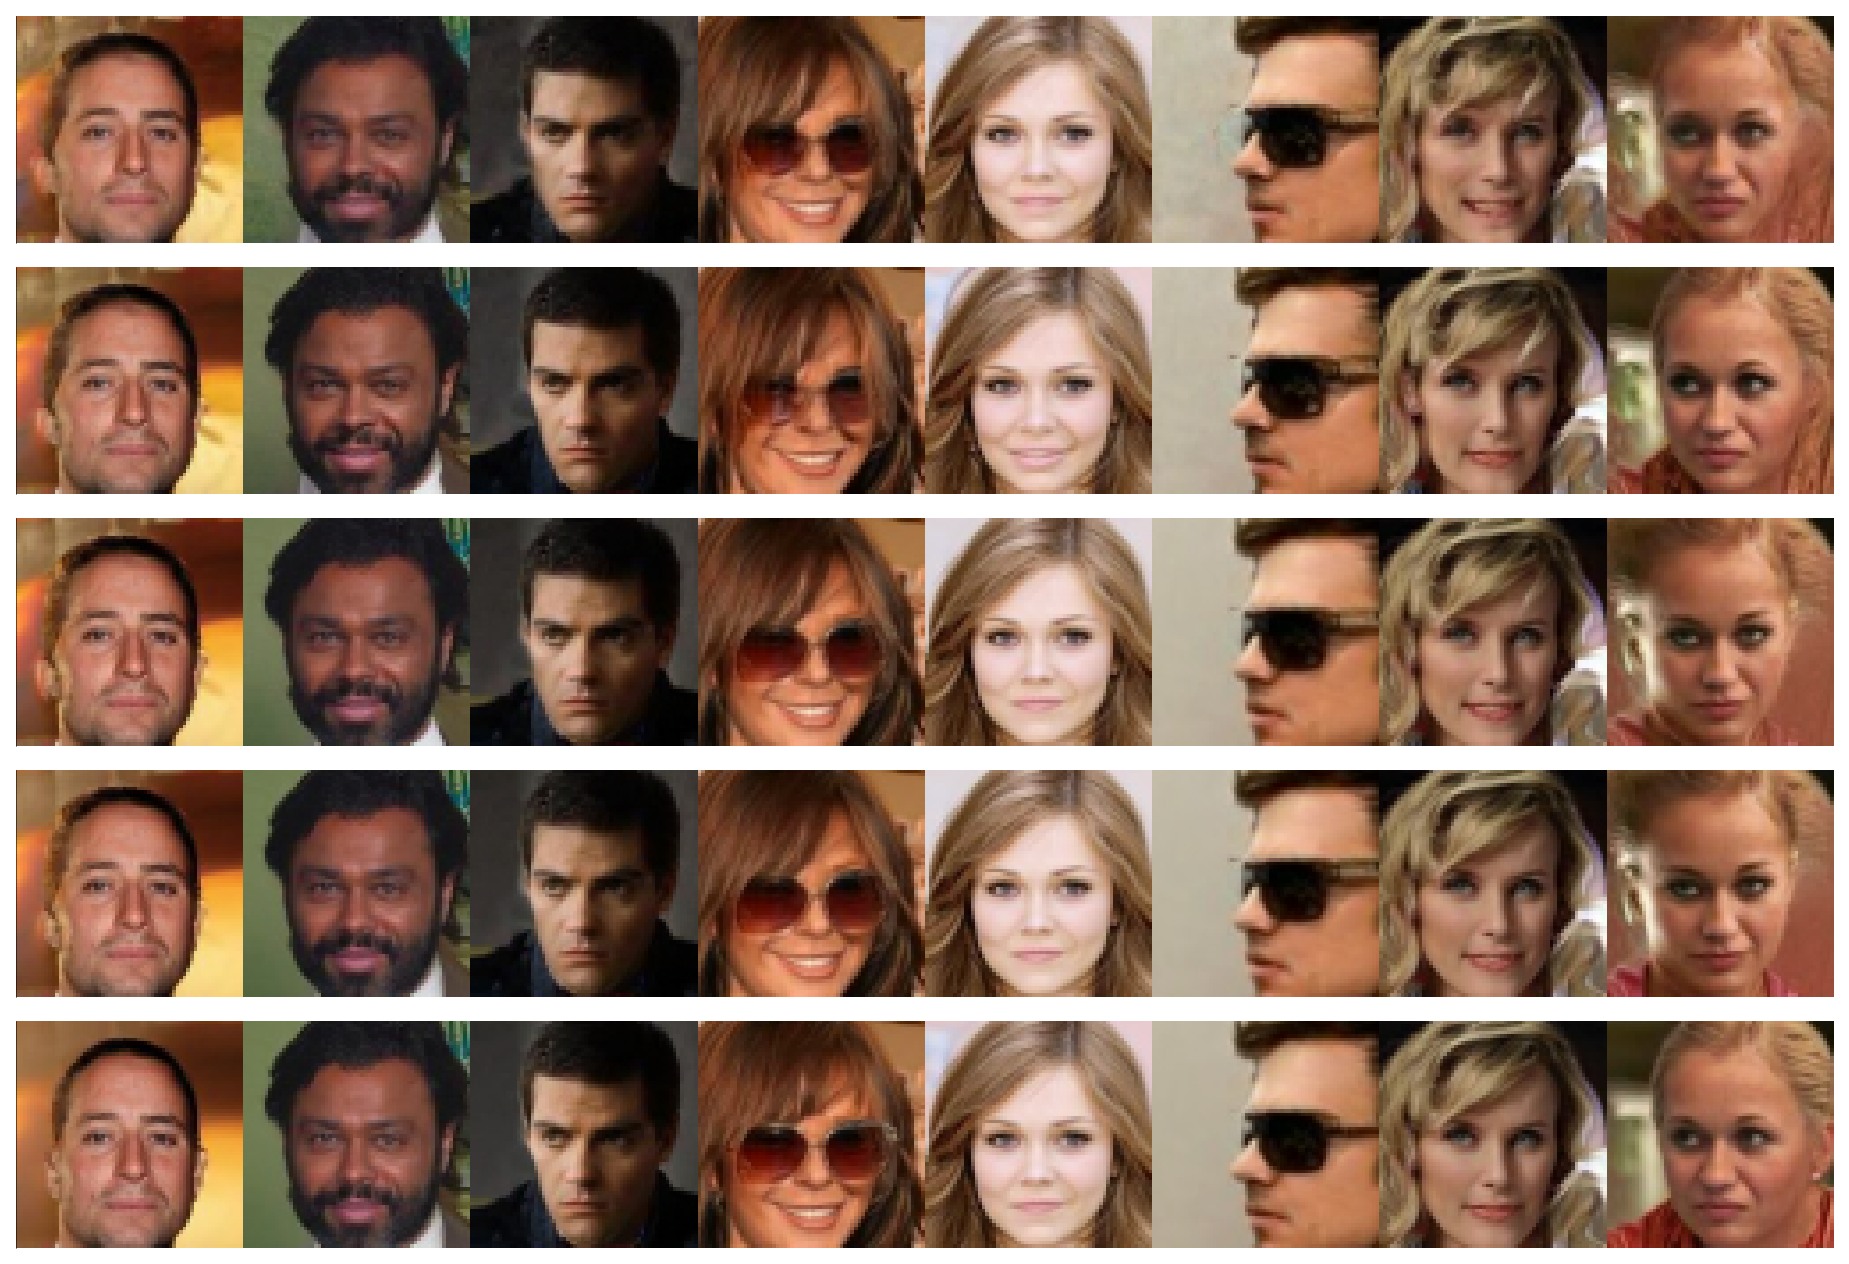


Sampling PSD-M
N= 1: Loading checkpoint  90 (FID=19.641)
Number of parameters: 124264485
N= 2: Loading checkpoint  85 (FID=11.747)
Number of parameters: 124264485
N= 4: Loading checkpoint 120 (FID=7.891)
Number of parameters: 124264485
N= 8: Loading checkpoint 120 (FID=6.064)
Number of parameters: 124264485
N=16: Loading checkpoint 120 (FID=5.093)
Number of parameters: 124264485
✓ Saved → celeba64_PSD-M_best.png


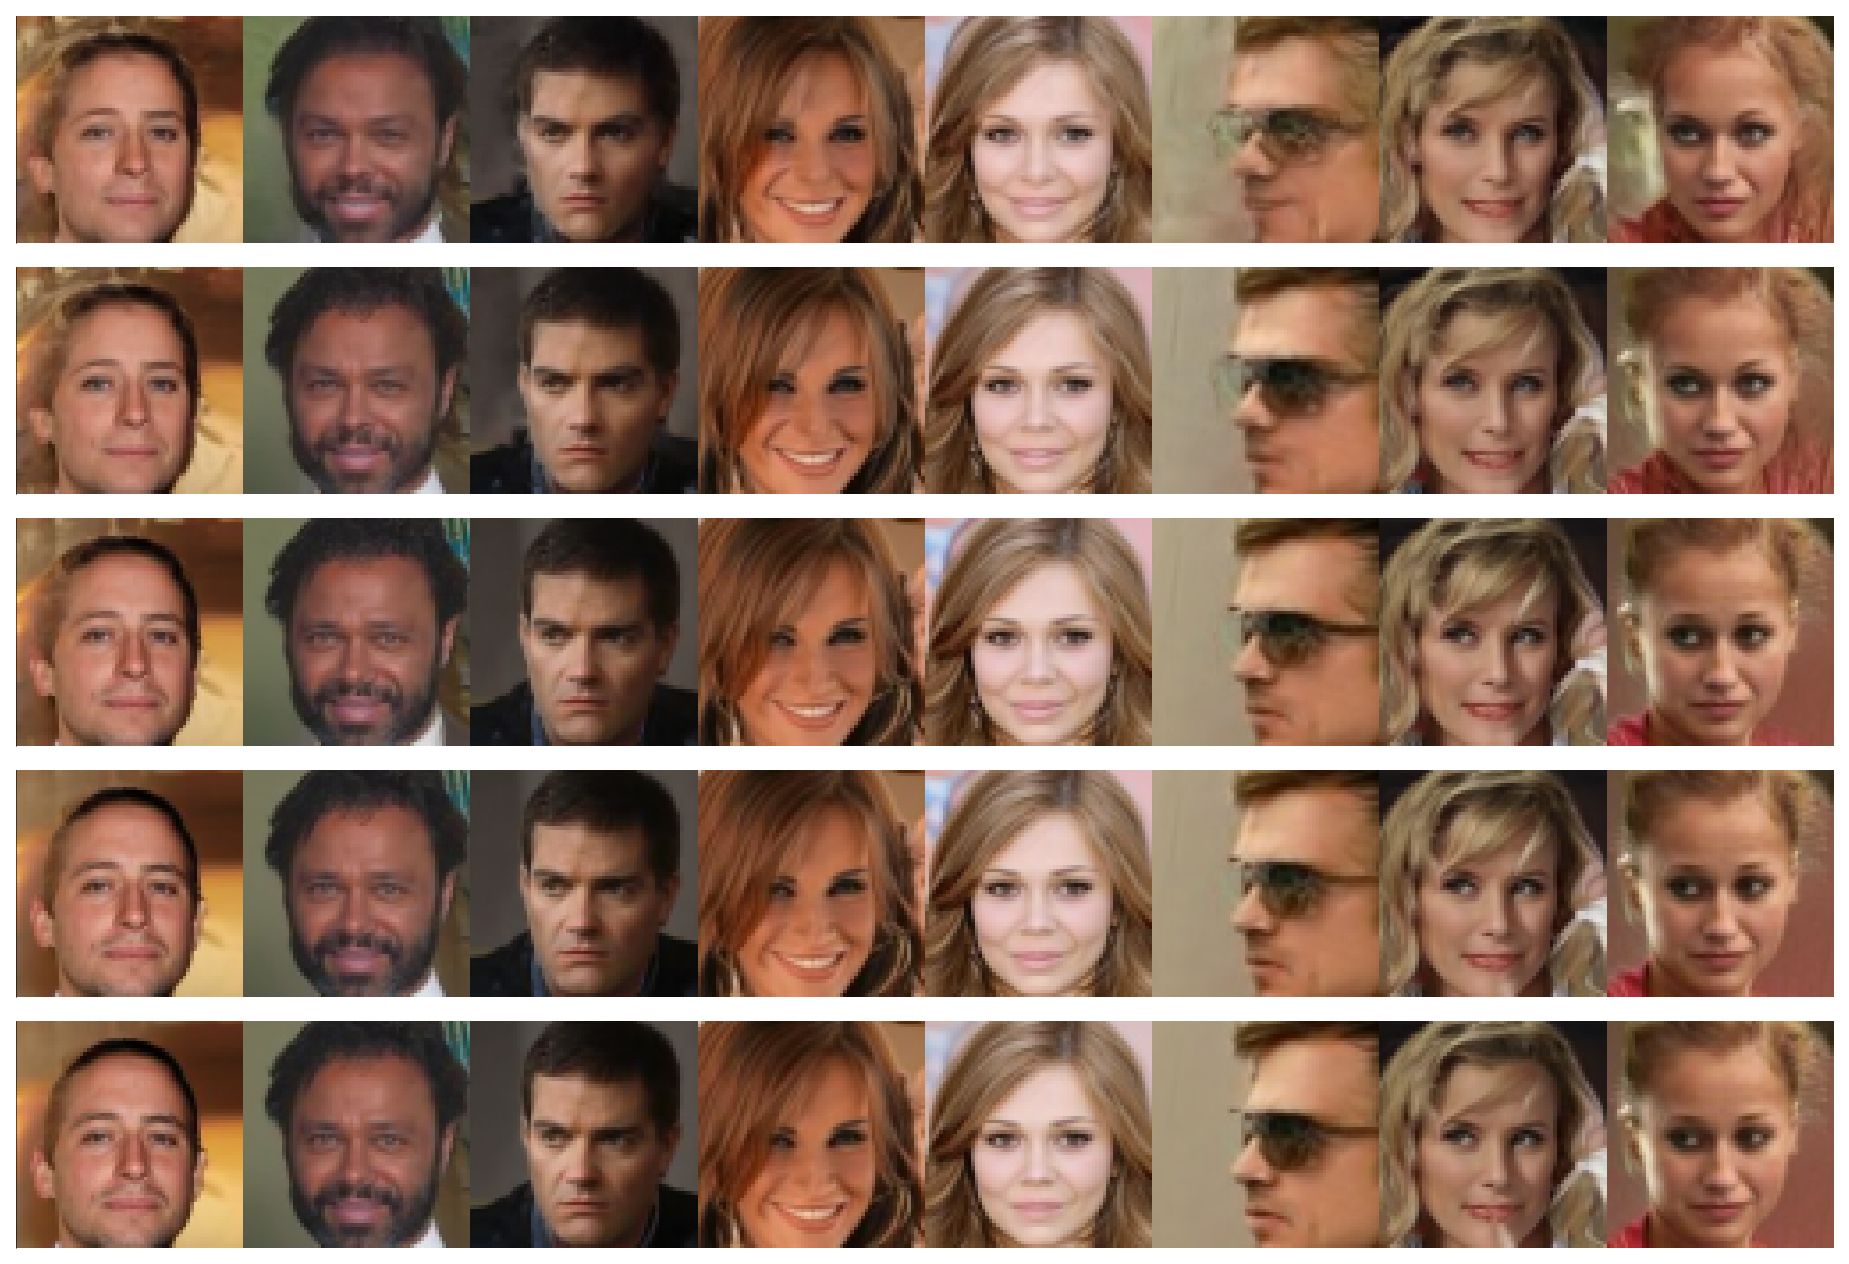


Sampling PSD-U
N= 1: Loading checkpoint  85 (FID=18.814)
Number of parameters: 124264485
N= 2: Loading checkpoint  85 (FID=11.023)
Number of parameters: 124264485
N= 4: Loading checkpoint  85 (FID=7.466)
Number of parameters: 124264485
N= 8: Loading checkpoint  80 (FID=5.997)
Number of parameters: 124264485
N=16: Loading checkpoint 125 (FID=5.627)
Number of parameters: 124264485
✓ Saved → celeba64_PSD-U_best.png


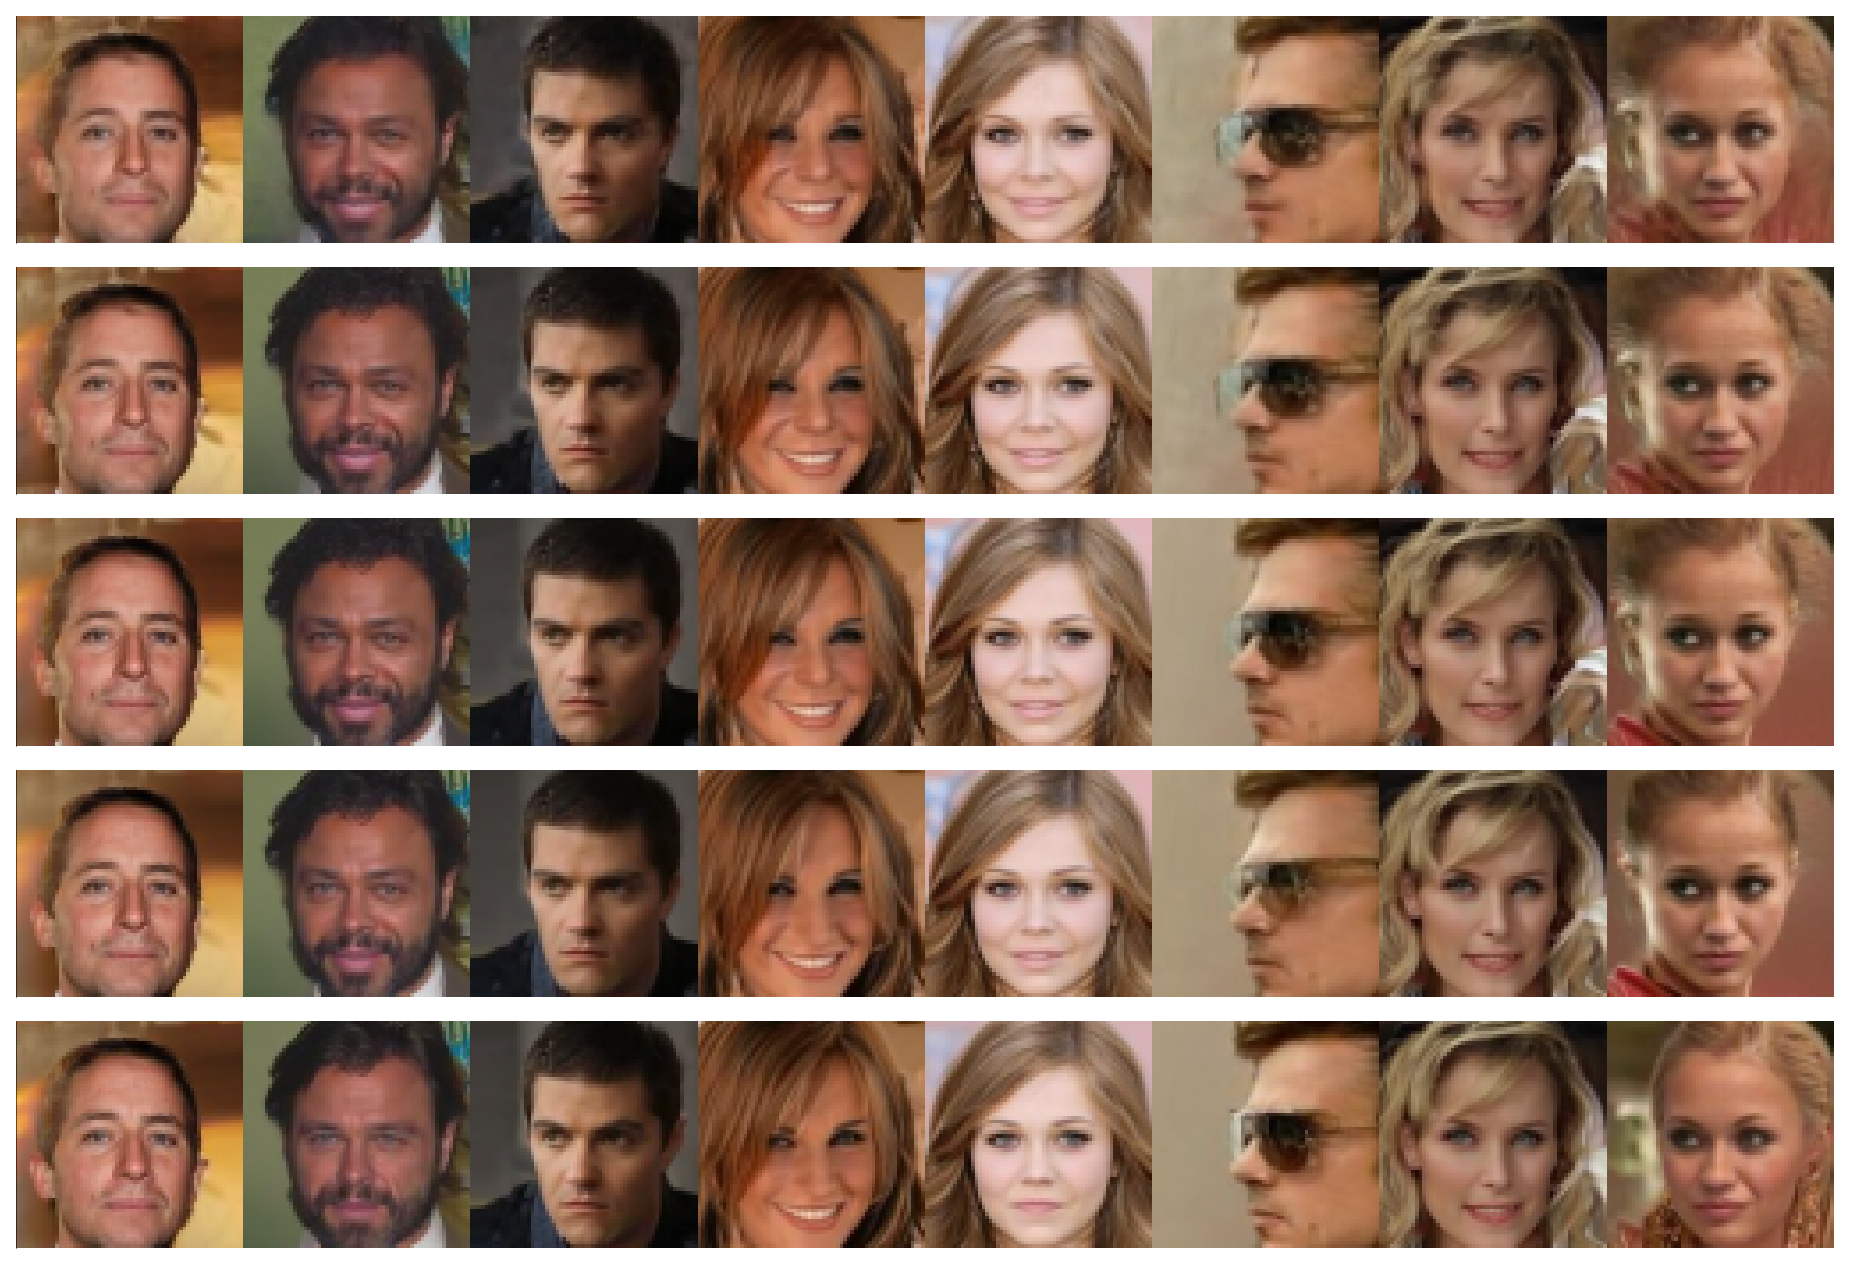


✓ Done!


In [20]:
import os, functools, importlib, jax, jax.numpy as jnp, numpy as np
import pandas as pd, glob, re
from matplotlib import pyplot as plt
import flax

plt.rcParams['text.usetex'] = False

# ==================== Configuration ====================
model_folder = "/n/netscratch/albergo_lab/Everyone/nmboffi/celeba"
fid_results_path = "/n/netscratch/albergo_lab/Everyone/nmboffi/celeba/fids"

# Map FID title prefixes to model configuration
TITLE_TO_CONFIG = {
    'fid_celeba_lsd_stopgrad_convex_diag75_bs256_9_8_resumed': {
        'base_name': 'celeba_lsd_stopgrad_convex_diag75_bs256_9_8_resumed',
        'slurm_id': 0,
        'cfg_module': 'configs.9_8_25_celeba_loss_method_resume',
        'label': 'LSD'
    },
    'fid_celeba_pfmm_shortcut_stopgrad_convex_diag75_bs256_9_8_resumed': {
        'base_name': 'celeba_pfmm_shortcut_stopgrad_convex_diag75_bs256_9_8_resumed',
        'slurm_id': 2,
        'cfg_module': 'configs.9_8_25_celeba_loss_method_resume',
        'label': 'PSD-M'
    },
    'fid_celeba_pfmm_uniform_stopgrad_convex_diag75_bs256_9_8_resumed': {
        'base_name': 'celeba_pfmm_uniform_stopgrad_convex_diag75_bs256_9_8_resumed',
        'slurm_id': 1,
        'cfg_module': 'configs.9_8_25_celeba_loss_method_resume',
        'label': 'PSD-U'
    }
}

N_STEPS = [1, 2, 4, 8, 16]
N_SHOW = 8
SEED = 32

# ==================== Load FID Results ====================
files = glob.glob(os.path.join(fid_results_path, "*.npz"))

# Use OLD format regex (no diag/date suffix)
rx_old = re.compile(
    r"""^
        (?P<title>.+)                  # everything before checkpoint
        _(?P<checkpoint>\d+)            # last number before ema
        _ema=(?P<ema>[0-9.]+)          # ema value
        _N=(?P<nsteps>\d+)             # N value
        \.npz$                         # extension
    """,
    re.VERBOSE,
)

records = []
for path in files:
    basename = os.path.basename(path)
    m = rx_old.match(basename)
    if m:
        with np.load(path) as z:
            fid = float(z["fid"])
        
        rec = m.groupdict()
        rec["checkpoint"] = int(rec["checkpoint"])
        rec["ema"] = float(rec["ema"])
        rec["nsteps"] = int(rec["nsteps"])
        rec["fid"] = fid
        records.append(rec)

df = pd.DataFrame(records)

print(f"Loaded {len(df)} FID records")
print(f"Unique titles: {df['title'].unique()}")

# Find best checkpoint for each (title, nsteps) combination
best_checkpoints = {}
for title, config in TITLE_TO_CONFIG.items():
    title_df = df[df['title'] == title]
    
    if len(title_df) == 0:
        print(f"⚠️  No data found for {title}")
        continue
    
    best_checkpoints[title] = {}
    
    print(f"\n{config['label']} ({title}):")
    for n in N_STEPS:
        n_df = title_df[title_df['nsteps'] == n]
        if len(n_df) > 0:
            best_idx = n_df['fid'].idxmin()
            best_row = n_df.loc[best_idx]
            best_checkpoints[title][n] = {
                'checkpoint': int(best_row['checkpoint']),
                'ema': float(best_row['ema']),
                'fid': float(best_row['fid'])
            }
            print(f"  N={n:2d} → checkpoint {best_row['checkpoint']:3d}, "
                  f"ema={best_row['ema']}, FID={best_row['fid']:.3f}")

# ==================== Sampling Functions ====================
def make_grid(imgs, n_cols=N_SHOW):
    B, H, W, C = imgs.shape
    n_rows = (B + n_cols - 1) // n_cols
    canvas = np.ones((n_rows*H, n_cols*W, C), dtype=imgs.dtype)
    for idx, im in enumerate(imgs):
        r, c = divmod(idx, n_cols)
        canvas[r*H:(r+1)*H, c*W:(c+1)*W] = im
    return canvas

def define_sampler(cfg):
    return (
        velocity.batch_sample if cfg.training.train_velocity else flow_map.batch_sample
    )

def sample_single_n(ckpt_path, ema, slurm_id, cfg_module, x0s, n_steps):
    """Sample with a specific checkpoint for a specific number of steps"""
    cfg = importlib.import_module(cfg_module).get_config(slurm_id, "", "")
    if cfg.problem.gaussian_scale == "adaptive":
        cfg.network.rescale = 0.5 if cfg.problem.target in {"mnist", "cifar10", "celeb_a"} else 1.0
    
    sampler_fn = define_sampler(cfg)
    
    # Initialize network
    net, params, _ = (
        velocity.initialize_velocity
        if cfg.training.train_velocity else flow_map.initialize_flow_map
    )(cfg.network, jnp.zeros(cfg.problem.image_dims), jax.random.PRNGKey(SEED))
    
    # Load checkpoint
    with open(ckpt_path, "rb") as f:
        dummy_tx, _ = state_utils.setup_optimizer(cfg)
        ts = state_utils.EMATrainState.create(
            apply_fn=net.apply, params=params, ema_params={ema: params}, tx=dummy_tx
        )
        ts = flax.serialization.from_bytes(ts, f.read())
    
    params = ts.ema_params[ema] if ema else ts.params
    
    # Sample
    imgs = sampler_fn(net.apply, params, x0s, n_steps, None)
    imgs = ((jnp.clip(imgs, -1, 1).transpose(0, 2, 3, 1) + 1) / 2).astype(np.float32)
    return make_grid(np.asarray(imgs))

# ==================== Generate Samples ====================
@functools.partial(jax.jit, static_argnums=(0,))
def sample_rho0(bs, key):
    return 0.5 * jax.random.normal(key, (bs, 3, 64, 64))

key = jax.random.PRNGKey(SEED)
x0s = sample_rho0(N_SHOW, key)

# Sample and visualize for each method
for title, config in TITLE_TO_CONFIG.items():
    if title not in best_checkpoints:
        print(f"⚠️  No checkpoints found for {title}")
        continue
    
    print(f"\n{'='*60}\nSampling {config['label']}\n{'='*60}")
    
    grids = []
    for n in N_STEPS:
        if n not in best_checkpoints[title]:
            print(f"⚠️  No checkpoint for N={n}, skipping")
            continue
        
        best = best_checkpoints[title][n]
        ckpt_path = f"{model_folder}/{config['base_name']}_{best['checkpoint']}.pkl"
        
        print(f"N={n:2d}: Loading checkpoint {best['checkpoint']:3d} (FID={best['fid']:.3f})")
        
        grid = sample_single_n(
            ckpt_path, 
            best['ema'], 
            config['slurm_id'], 
            config['cfg_module'], 
            x0s, 
            n
        )
        grids.append(grid)
    
    # Create visualization
    n_rows = len(grids)
    fig, axes = plt.subplots(
        n_rows, 1,
        figsize=(N_SHOW*1.6, n_rows*1.6),
        dpi=160,
        tight_layout=True
    )
    if n_rows == 1:
        axes = [axes]
    
    for ax, grid, n in zip(axes, grids, N_STEPS[:len(grids)]):
        ax.imshow(grid)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel("")
        for spine in ("top", "right", "bottom"):
            ax.spines[spine].set_visible(False)
    
    # Save
    out_name = f"celeba64_{config['label'].replace(' ', '_')}_best.png"
    fig.savefig(out_name, dpi=160, bbox_inches="tight")
    print(f"✓ Saved → {out_name}")
    plt.show()

print("\n✓ Done!")